In [24]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [33]:
# Load Dataset
df = pd.read_excel("Cleaned_Dataset_Project1_Final.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
# Shape
df.shape

(1200, 14)

In [6]:
# Columns
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [34]:
# Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [8]:
# Missing Values
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [9]:
# Numerical Statistics
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [10]:
# Mean
df.mean(numeric_only=True)

Quantity          2.945833
UnitPrice       356.412750
ItemsInCart       5.485000
TotalPrice     1053.968300
dtype: float64

In [11]:
# median
df.median(numeric_only=True)

Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64

In [12]:
# count
df.count()

OrderID            1200
Date               1200
CustomerID         1200
Product            1200
Quantity           1200
UnitPrice          1200
ShippingAddress    1200
PaymentMethod      1200
OrderStatus        1200
TrackingNumber     1200
ItemsInCart        1200
CouponCode         1200
ReferralSource     1200
TotalPrice         1200
dtype: int64

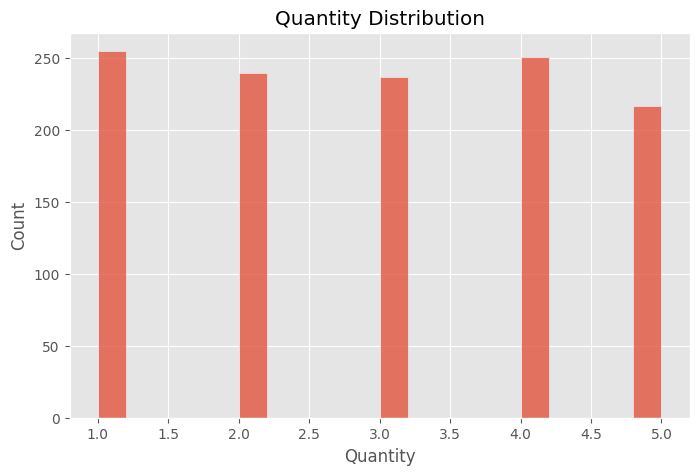

In [32]:
# Quantity Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=20)
plt.title("Quantity Distribution")
plt.show()

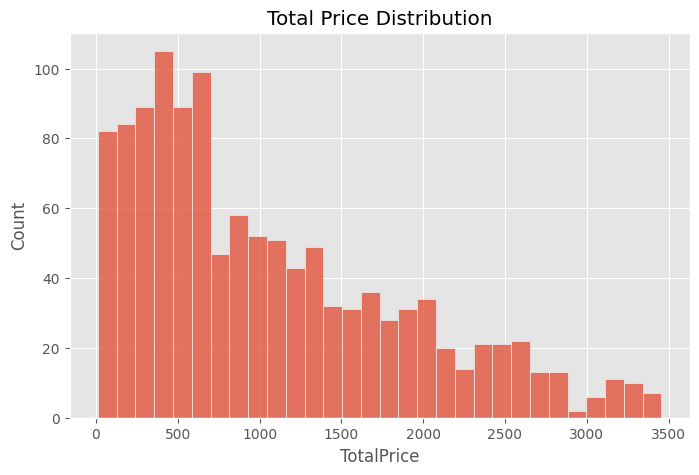

In [14]:
# Total Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['TotalPrice'], bins=30)
plt.title("Total Price Distribution")
plt.show()

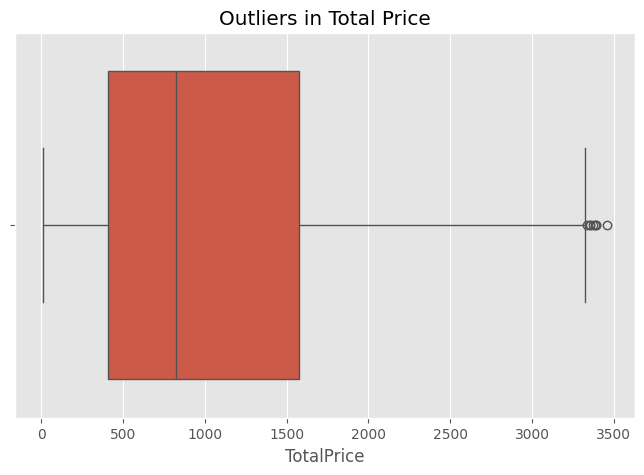

In [15]:
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['TotalPrice'])
plt.title("Outliers in Total Price")
plt.show()

In [16]:
# IQR Method
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['TotalPrice'] < lower) |
              (df['TotalPrice'] > upper)]

print("Outliers Found:", len(outliers))

Outliers Found: 8


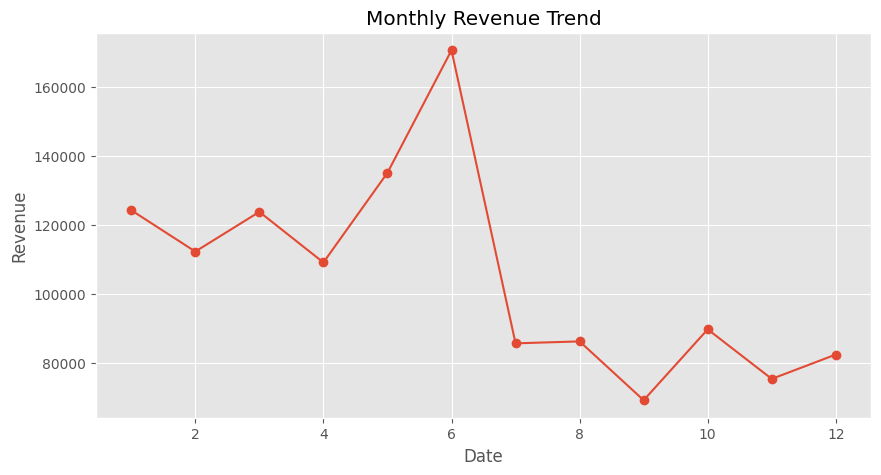

In [17]:
# Monthly Revenue Trend
df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = df.groupby(
    df['Date'].dt.month
)['TotalPrice'].sum()

monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

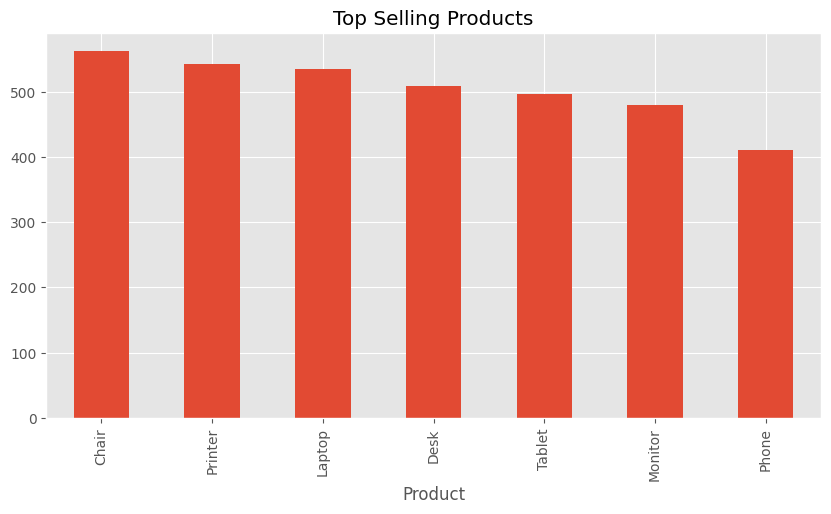

In [18]:
# Top Selling Products
top_products = df.groupby(
    'Product'
)['Quantity'].sum().sort_values(
    ascending=False
)

top_products.plot(
    kind='bar',
    figsize=(10,5)
)
plt.title("Top Selling Products")
plt.show()

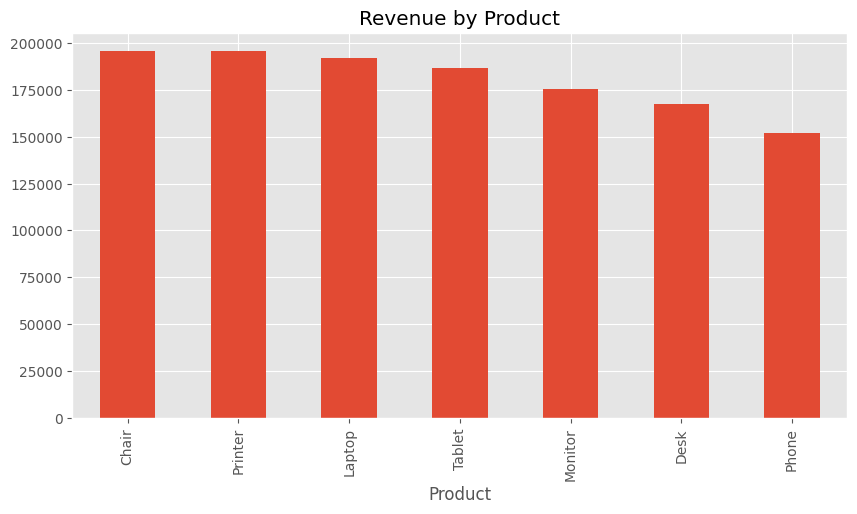

In [19]:
# Revenue Analysis
revenue_product = df.groupby(
    'Product'
)['TotalPrice'].sum().sort_values(
    ascending=False
)

revenue_product.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Revenue by Product")
plt.show()

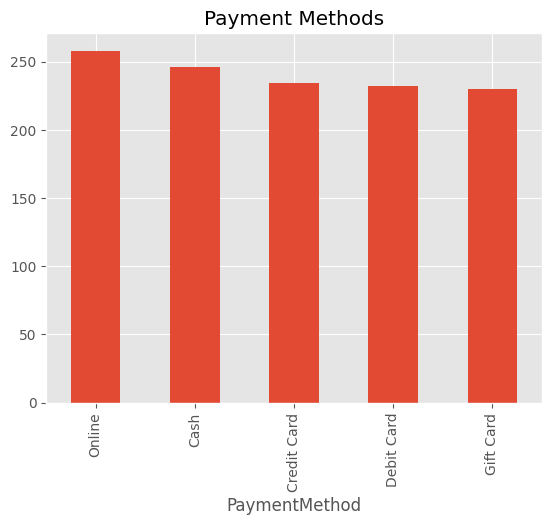

In [20]:
# Payment Method Analysis
df['PaymentMethod'].value_counts().plot(
    kind='bar'
)

plt.title("Payment Methods")
plt.show()

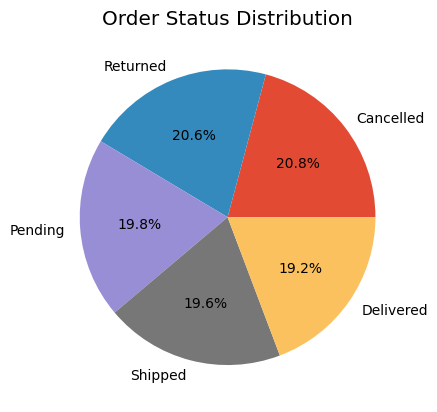

In [21]:
# Order Status Analysis
df['OrderStatus'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Order Status Distribution")
plt.show()

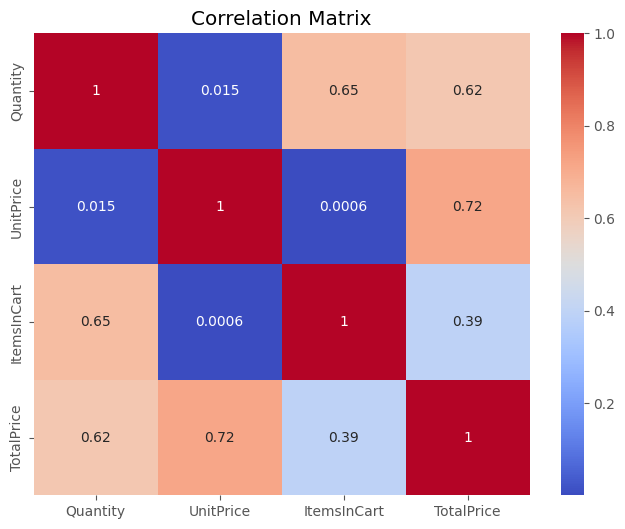

In [22]:
# Correlation Analysis
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Quantity',
        'UnitPrice',
        'ItemsInCart',
        'TotalPrice']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [35]:
# Save EDA project
df.to_excel("Exploratory_Data_Analysis_(EDA)_Project2.xlsx", index=False)